(chap-exploring_a_database)=
# Exploring a database


```{important}
Usually, directories of experimental records are produced by colleagues in the lab. It is essential that there is ongoing discussion between the experimentalists and the people who will later analyze the data, such as data scientists. If data scientists modify the structure of the records directory, it becomes much harder to maintain this communication and can significantly slow down the process of data exploitation and analysis. Therefore, following good practices for organizing and managing the data is crucial.
```

We consider a dataset in `data/records_fake`.  

This dataset consists of a set of (empty) records compiled in 2024, from March 15 to June 26, by [Joanna Danielewicz](https://www.linkedin.com/in/joanna-danielewicz-522139b6/?originalSubdomain=es) at the [Mathematical, Computational and Experimental](https://www.bcamath.org/en/research/areas/m3a/mcen) lab, headed by [Serafim Rodrigues](https://www.ikerbasque.net/es/serafim-rodrigues) at [BCAM](https://www.bcamath.org/en).  

The directory structure is the same as in the real dataset, but the files are empty, since the original recordings are too large. Later, we will work with selected real recordings.

In the `data` directory I have a subdirectory `records_fake` that contains empty `abf` and `atf` files, the structure is:

In [1]:
!tree -L 2 data/records_fake

data/records_fake
├── 03.15
│   ├── C1
│   └── C2
├── 03.20
│   └── C1
├── 04.10
│   ├── C1
│   ├── C2\ immature
│   └── C3
├── 05.07
│   ├── C1\ DG
│   └── C2\ DG
├── 05.20
│   ├── C1
│   ├── C2
│   ├── C3
│   ├── C4
│   └── C5
├── 05.23
│   ├── C1
│   ├── C2
│   ├── C3
│   └── C4
├── 05.29
│   ├── C1
│   ├── C2
│   └── C3\ immature
├── 05.30
│   ├── C1
│   └── C2
├── 06.19
│   ├── C1
│   └── C2
├── 06.26
│   ├── C1
│   ├── C2
│   └── C3
└── README.md

37 directories, 1 file


First we  present somes good practices about records directory.

## Good practrices about records directory


### Directory structure: flatten or not?

- Keep the hierarchy (date → cell → files).
- It mirrors the experimental workflow (date of recording, then cell).
- Easier to reason about provenance ("what did we do on May 30?").
- Helps you separate sessions and avoid accidental filename collisions.
- Flattening could be useful for scripts, but you can always create virtual flattening in Python (e.g., by walking the directory tree). So I’d keep the hierarchy and let code do the flattening.

**Recommendation:** Keep the directory hierarchy. Use scripts to index/flatten when needed.

### Metadata handling

- Do not rely only on filenames — they’re fragile and inconsistent.
- Best practice: keep a `metadata` table (CSV, TSV, JSON, YAML, or SQLite DB), eg. a `metadata.csv` to store all experiment details.  
  - You can add or correct metadata later without touching raw files.  
  - Easy to query and filter in Python (e.g., with `pandas`).  
  - Prevents the need to rename files whenever metadata changes.  

**Recommendation:** Maintain a single central metadata file (CSV for simplicity, or SQLite if the dataset grows large).  

### `README.md`

Add a `README.md` in the data file that includes:
- Directory structure
- Naming conventions
- Protocol/temperature shorthand
- Instructions for using metadata

### File Naming

- Keep original filenames from acquisition (ground truth).
- Do not overwrite raw files.
- If you want clean names, create symbolic links or derived copies like: `cellID_date_protocol.abf`, eg. you can make a (flat) dir of symbolic links:
```
symlinks/
├── C21_05.30.abf
├── C22_05.30.abf
├── C23_06.19.abf
```

### Keep raw data read-only

- Protects raw data integrity → accidental edits, renames, or deletions won’t happen.
- Clear separation between:
   - Raw data (immutable, read-only)
   - Derived data / analysis results (reproducible, regeneratable)
- Works well with the principle: “never touch your raw data, always derive.”
- In multi-user setups (lab server, shared cluster), permissions protect against colleagues accidentally overwriting.

**Things to keep in mind**
- You may still want to add new files (new experiments) → so you don’t want to lock the whole records root permanently. Instead, set read-only permissions per experiment once it’s finalized.
- If you ever need to move or reorganize, you’ll have to re-enable write permissions (chmod u+w).
- A safer alternative:
   - Keep raw records as read-only
   - Mirror it to a version-controlled metadata database (metadata.csv or SQLite), which you can edit freely




## Back to the case study

To make everything in 'data/records_fake/' read-only:

In [2]:
!chmod -R a-w data/records_fake
!ls -l data/records_fake/*/*/* | head -n 5

-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0000 IC steps 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0001 IC ramp 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0002 IC sin 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0003 VC ramp 23.abf
-r--r--r--  1 campillo  staff  0 29 sep 21:24 data/records_fake/03.15/C1/2024_03_15_0004 IC ramp 25.abf
ls: stdout: Undefined error: 0


Now everybody (owner, group, all) car read the files but cannot write (or execute), files can still be read and copied. Still under MacOS with `Finder` you can make some damages, you can make them immutable:

In [3]:
!chflags -R uchg data/records_fake

Note the little locker in Finder:

![chflags](pics/chflags.png)

(To undo: `chflags -R nouchg records`)



```{tip}
Best practices
- Keep raw data untouched.
- Keep raw data read-only once experiments are finalized.
- Track metadata in metadata.csv — symlinks are just for easier file access, not metadata storage.
- If necessary, use symlinks for convenience (clean naming, flat access).
```

## pandas DataFrame

**pandas DataFrame** (df) is far better than built-in Python tools like lists, dictionaries, or arrays for the following reasons:

- Tabular structure built-in
   - A DataFrame behaves like a table or spreadsheet: rows = records, columns = fields.
   - You don’t have to manually manage parallel lists or nested dictionaries.
- Easy indexing and filtering: doing the same with lists/dicts would require loops and conditionals — much more verbose
- Powerful aggregation & grouping: compute counts, averages, sums, or custom statistics without writing loops
- Built-in handling of missing data
   - Pandas understands `NaN` values automatically.
   - Built-in functions handle missing data gracefully.
- Integration with plotting and analysis
- Easy I/O; Load/save CSV, Excel, SQL, JSON, and more with a single command.

See infra.



## Back to the cas study

**This part is as necessary as it is boring !** 
From `data/records_fake` (which we will not modify), we generate a metadata file `data/records_fake.csv` in CSV format. The procedure is somewhat tricky and was developed **step by step** with the help of ChatGPT.

In [7]:
# ___ create a csv cell_id, pathname, filename

import pathlib
import csv
from pathlib import Path

# Paths
records_root = pathlib.Path("data/records_fake")
metadata_file = pathlib.Path("data/records_fake_metadata.csv")

# Collect metadata
rows = []

# Absolute cell counter
absolute_cell_counter = 1

# Sort day folders chronologically by folder name (MM.DD)
day_folders = sorted([d for d in records_root.iterdir() if d.is_dir()])

for day_folder in day_folders:
    # Sort cell folders within the day
    cell_folders = sorted([c for c in day_folder.iterdir() if c.is_dir()])
    
    for cell_folder in cell_folders:
        # Absolute cell ID
        cell_id = f"C{absolute_cell_counter}"
        absolute_cell_counter += 1
        
        # Process all files in the cell folder
        for f in sorted(cell_folder.iterdir()):
            if f.is_file():
                rows.append({
                    "cell_id": cell_id,
                    "file_path": str(f.relative_to(records_root)),
                    "file_name": f.name
                })

# Define fieldnames
fieldnames = ["cell_id", "file_path", "file_name"]

# Write CSV
with open(metadata_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Metadata CSV written to {metadata_file}, total files: {len(rows)}")


Metadata CSV written to data/records_fake_metadata.csv, total files: 659


In [8]:
import pandas as pd

# Load the metadata
df = pd.read_csv("data/records_fake_metadata.csv")

# Display the first few rows
df.head()

,cell_id,file_path,file_name
0,C1,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,C1,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,C1,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,C1,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,C1,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


In [9]:
# ___ add date column


# Paths
metadata_file = Path("data/records_fake_metadata.csv")
metadata_file_2 = Path("data/records_fake_metadata_2.csv")
records_root = Path("data/records_fake")

# Load existing CSV
df = pd.read_csv(metadata_file)

# Function to extract date from file_path
def extract_date(file_path_str):
    file_path = Path(file_path_str)
    # Parent of the cell folder is the day folder: 03.15, 03.20, ...
    day_folder = file_path.parent.parent.name
    try:
        month, day = day_folder.split(".")
        return f"2024-{month}-{day}"  # YYYY-MM-DD
    except ValueError:
        return "2024-01-01"  # fallback if malformed

# Apply function
df['date'] = df['file_path'].apply(extract_date)

# Reorder columns: cell_id, date, file_path, file_name
df = df[['cell_id', 'date', 'file_path', 'file_name']]

# Save new CSV
df.to_csv(metadata_file_2, index=False)

print(f"Metadata updated with 'date', saved to {metadata_file_2}")


Metadata updated with 'date', saved to data/records_fake_metadata_2.csv


In [10]:
# Load the metadata
df = pd.read_csv("data/records_fake_metadata_2.csv")

# Display the first few rows
df.head()

,cell_id,date,file_path,file_name
0,C1,2024-03-15,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,C1,2024-03-15,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,C1,2024-03-15,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,C1,2024-03-15,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,C1,2024-03-15,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


In [11]:
# ___ add the experiment number in first column 

# Paths
metadata_file_2 = Path("data/records_fake_metadata_2.csv")
metadata_file_3 = Path("data/records_fake_metadata_3.csv")

# Load existing CSV
df = pd.read_csv(metadata_file_2)

# Add 'eco_nb' column as the first column, incrementing from 1
df.insert(0, 'exp_nb', range(1, len(df) + 1))

# Save the updated CSV
df.to_csv(metadata_file_3, index=False)

print(f"'exp_nb' added, saved to {metadata_file_3}")


'exp_nb' added, saved to data/records_fake_metadata_3.csv


In [12]:
# Load the metadata
df = pd.read_csv("data/records_fake_metadata_3.csv")

# Display the first few rows
df.head()

,exp_nb,cell_id,date,file_path,file_name
0,1,C1,2024-03-15,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,2,C1,2024-03-15,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,3,C1,2024-03-15,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,4,C1,2024-03-15,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,5,C1,2024-03-15,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


In [13]:
# Load the CSV
df = pd.read_csv("data/records_fake_metadata_3.csv")

# Build the comments column
comments = []
for path in df["file_path"]:
    tags = []
    if "immature" in path.lower():
        tags.append("immature")
    if "dead" in path.lower():
        tags.append("dead")
    comments.append(";".join(tags))

# Insert the comments column right after "date"
date_index = df.columns.get_loc("date")
df.insert(date_index + 1, "comments", comments)

# Save to new CSV
df.to_csv("data/records_fake_metadata_4.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_4.csv")


✅ New file saved as data/records_fake_metadata_4.csv


In [25]:
import pandas as pd

# Load previous CSV
df = pd.read_csv("data/records_fake_metadata_4.csv")

protocols = []
new_comments = []

for path, comment in zip(df["file_path"], df["comments"]):
    path_lower = path.lower()
    updated_comment = comment if pd.notna(comment) else ""

    # Determine protocol
    if "dynamic clamp" in path_lower or " dc" in path_lower or path_lower.endswith("dc.abf"):
        protocol = "DC"
        # Add IC to comments only if IC actually exists in path
        if " ic" in path_lower or path_lower.startswith("ic") or " ic." in path_lower:
            if updated_comment:
                if "IC" not in updated_comment.split(";"):
                    updated_comment += ";IC"
            else:
                updated_comment = "IC"
    elif "vc" in path_lower:
        protocol = "VC"
    elif "ic" in path_lower:
        protocol = "IC"
    else:
        protocol = ""

    protocols.append(protocol)
    new_comments.append(updated_comment)

# Insert protocol column after 'date'
date_index = df.columns.get_loc("date")
df.insert(date_index + 1, "protocol", protocols)

# Update comments
df["comments"] = new_comments

# Save new CSV
df.to_csv("data/records_fake_metadata_5.csv", index=False)

print("✅ Updated file saved as data/records_fake_metadata_5.csv")


✅ Updated file saved as data/records_fake_metadata_5.csv


In [26]:
import pandas as pd

# Load CSV
df = pd.read_csv("data/records_fake_metadata_5.csv")

prot_opt_list = []

for path in df["file_path"]:
    path_lower = path.lower()
    prot_opt = ""
    
    if " steps " in path_lower:
        prot_opt = "steps"
    elif " step " in path_lower:
        prot_opt = "step"
    elif " ramp " in path_lower:
        prot_opt = "ramp"
    elif " sin " in path_lower:
        prot_opt = "sin"
    
    prot_opt_list.append(prot_opt)

# Insert new column after "protocol"
protocol_index = df.columns.get_loc("protocol")
df.insert(protocol_index + 1, "prot-opt", prot_opt_list)

# Save updated CSV
df.to_csv("data/records_fake_metadata_6.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_6.csv")


✅ New file saved as data/records_fake_metadata_6.csv


In [30]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("data/records_fake_metadata_6.csv")

tp_list = []

for path in df["file_path"]:
    # Match last 2-digit number, optionally with comma and digit, before file extension
    match = re.search(r"(\d{2}(?:,\d)?)\s*(?=[^\d]*\.(?:abf|atf)$)", path, re.IGNORECASE)
    if match:
        tp = match.group(1).replace(",", ".")  # convert comma to dot
    else:
        tp = ""
    tp_list.append(tp)

# Insert "tp" column after "prot-opt"
prot_opt_index = df.columns.get_loc("prot-opt")
df.insert(prot_opt_index + 1, "tp", tp_list)

# Ensure tp is string (dot as decimal separator)
df["tp"] = df["tp"].astype(str)

# Save updated CSV
df.to_csv("data/records_fake_metadata_7.csv", index=False)

print("✅ New file saved as data/records_fake_metadata_7.csv")


✅ New file saved as data/records_fake_metadata_7.csv


**HERE**

I also use `csvlook` under terminal: Renders a CSV to the command line in a Markdown-compatible, fixed-width format.


** donne plus de détails **

In [32]:
!csvcut -c file_name data/records_fake_metadata_7.csv | grep -vE "\.(abf|atf)\"?$"

file_name
2024_05_23_0020.rsv
2024_05_30_0001_metadata.json
2024_05_30_0001_metadata.txt
2024_05_30_0010_metadata.json
2024_05_30_0010_metadata.txt
2024_05_30_0017_metadata.json
2024_05_30_0017_metadata.txt
2024_05_30_0023_metadata.json


the previous files are useless, how to suppress ?

also if I do
```bash
csvcut -c file_name records_fake_metadata_7.csv | csvlook
```
i see all the file names, and I see that some files are useless:
```
| CC.atf                                 |
| CC2.atf                                |
| INTRES1.atf                            |
| INTRES2.atf                            |
| VC.atf                                 |
| VC2.atf                                |
| VC3.atf                                |
```


## Exploring the metadata

In [20]:
import pandas as pd

# Load the metadata
df = pd.read_csv("data/records_fake.csv")

# Display the first few rows
df.head()

,cell_id,date,experiment_number,protocol,protocol_option,temperature,comments,file_path,file_name
0,C1,2024-03-15,0.0,IC,steps,NaN,23abf,03.15/C1/2024_03_15_0000 IC steps 23.abf,2024_03_15_0000 IC steps 23.abf
1,C1,2024-03-15,1.0,IC,ramp,NaN,23abf,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
2,C1,2024-03-15,2.0,IC,sin,NaN,23abf,03.15/C1/2024_03_15_0002 IC sin 23.abf,2024_03_15_0002 IC sin 23.abf
3,C1,2024-03-15,3.0,VC,ramp,NaN,23abf,03.15/C1/2024_03_15_0003 VC ramp 23.abf,2024_03_15_0003 VC ramp 23.abf
4,C1,2024-03-15,4.0,IC,ramp,NaN,25abf,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf


In [21]:
# Get number of files, columns, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cell_id            651 non-null    object 
 1   date               431 non-null    object 
 2   experiment_number  431 non-null    float64
 3   protocol           138 non-null    object 
 4   protocol_option    138 non-null    object 
 5   temperature        0 non-null      float64
 6   comments           651 non-null    object 
 7   file_path          651 non-null    object 
 8   file_name          651 non-null    object 
dtypes: float64(2), object(7)
memory usage: 45.9+ KB


In [22]:
# Show unique protocols nicely
print("Unique protocols:", df['protocol'].unique())

# Count files per protocol
protocol_counts = df['protocol'].value_counts()
print("\nFiles per protocol:")
print(protocol_counts.to_string())

# Count files per day
day_counts = df['date'].value_counts()
print("\nFiles per day:")
print(day_counts.to_string())

Unique protocols: ['IC' 'VC' nan]

Files per protocol:
protocol
IC    94
VC    44

Files per day:
date
2024-05-23    70
2024-03-15    67
2024-05-20    51
2024-06-26    49
2024-04-10    38
2024-05-30    38
2024-05-07    37
2024-05-29    37
2024-06-19    24
2024-03-20    20


In [23]:
#Use pandas styling (works in Jupyter Notebook)

# Count files per protocol
df['protocol'].value_counts().sort_index().to_frame().style.set_caption("Files per Protocol").format("{:.0f}")

# Count files per day
df['date'].value_counts().sort_index().to_frame().style.set_caption("Files per Day").format("{:.0f}")


,count
date,
2024-03-15,67
2024-03-20,20
2024-04-10,38
2024-05-07,37
2024-05-20,51
2024-05-23,70
2024-05-29,37
2024-05-30,38
2024-06-19,24


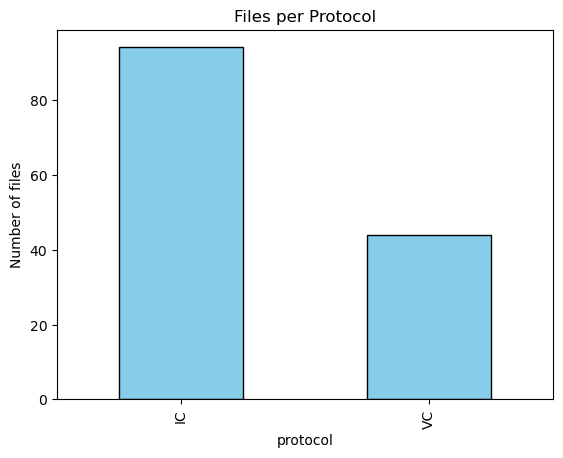

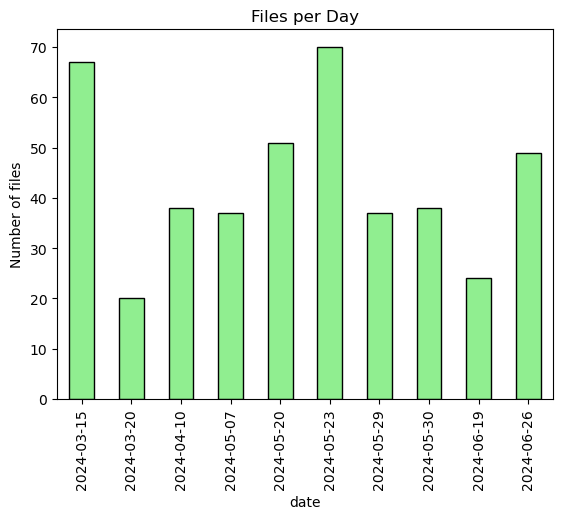

In [24]:
import matplotlib.pyplot as plt

# Files per protocol
protocol_counts = df['protocol'].value_counts()
protocol_counts.plot(kind='bar', color='skyblue', edgecolor='black', title='Files per Protocol')
plt.ylabel('Number of files')
plt.show()

# Files per day
day_counts = df['date'].value_counts().sort_index()
day_counts.plot(kind='bar', color='lightgreen', edgecolor='black', title='Files per Day')
plt.ylabel('Number of files')
plt.show()

## Filtering

### All dead cells experiments

In [26]:
# Filter rows where comments contain 'dead' (case-insensitive)
dead_cells = df[df['comments'].str.contains('dead', case=False, na=False)]

# Display the result
dead_cells

,cell_id,date,experiment_number,protocol,protocol_option,temperature,comments,file_path,file_name
66,C2,2024-03-15,66.0,IC,ramp,NaN,38 deadabf,03.15/C2/2024_03_15_0066 IC ramp 38 dead.abf,2024_03_15_0066 IC ramp 38 dead.abf
634,C26,2024-06-26,32.0,NaN,NaN,NaN,25 DC deadabf,06.26/C2/2024_06_26_0032 25 DC dead.abf,2024_06_26_0032 25 DC dead.abf


### All experiment of the day '2024-05-29'

In [27]:
# Filter rows for a specific day
day_data = df[df['date'] == '2024-05-29']

# Display the result
day_data

,cell_id,date,experiment_number,protocol,protocol_option,temperature,comments,file_path,file_name
459,C18,2024-05-29,0.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0000.abf,2024_05_29_0000.abf
460,C18,2024-05-29,1.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0001.abf,2024_05_29_0001.abf
461,C18,2024-05-29,2.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0002.abf,2024_05_29_0002.abf
462,C18,2024-05-29,3.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0003.abf,2024_05_29_0003.abf
463,C18,2024-05-29,4.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0004.abf,2024_05_29_0004.abf
464,C18,2024-05-29,5.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0005.abf,2024_05_29_0005.abf
465,C18,2024-05-29,6.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0006.abf,2024_05_29_0006.abf
466,C18,2024-05-29,7.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0007.abf,2024_05_29_0007.abf
467,C18,2024-05-29,8.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0008.abf,2024_05_29_0008.abf
468,C18,2024-05-29,9.0,NaN,NaN,NaN,abf,05.29/C1/2024_05_29_0009.abf,2024_05_29_0009.abf


### All `IC ramp` 

In [28]:
# Filter rows with protocol 'IC' and protocol_option 'ramp'
ic_ramp_cells = df[(df['protocol'] == 'IC') & (df['protocol_option'] == 'ramp')]

# Display the result
ic_ramp_cells

,cell_id,date,experiment_number,protocol,protocol_option,temperature,comments,file_path,file_name
1,C1,2024-03-15,1.0,IC,ramp,NaN,23abf,03.15/C1/2024_03_15_0001 IC ramp 23.abf,2024_03_15_0001 IC ramp 23.abf
4,C1,2024-03-15,4.0,IC,ramp,NaN,25abf,03.15/C1/2024_03_15_0004 IC ramp 25.abf,2024_03_15_0004 IC ramp 25.abf
7,C1,2024-03-15,7.0,IC,ramp,NaN,27abf,03.15/C1/2024_03_15_0007 IC ramp 27.abf,2024_03_15_0007 IC ramp 27.abf
10,C1,2024-03-15,10.0,IC,ramp,NaN,29abf,03.15/C1/2024_03_15_0010 IC ramp 29.abf,2024_03_15_0010 IC ramp 29.abf
13,C1,2024-03-15,13.0,IC,ramp,NaN,31abf,03.15/C1/2024_03_15_0013 IC ramp 31.abf,2024_03_15_0013 IC ramp 31.abf
16,C1,2024-03-15,16.0,IC,ramp,NaN,34abf,03.15/C1/2024_03_15_0016 IC ramp 34.abf,2024_03_15_0016 IC ramp 34.abf
20,C1,2024-03-15,20.0,IC,ramp,NaN,36abf,03.15/C1/2024_03_15_0020 IC ramp 36.abf,2024_03_15_0020 IC ramp 36.abf
23,C1,2024-03-15,23.0,IC,ramp,NaN,38abf,03.15/C1/2024_03_15_0023 IC ramp 38.abf,2024_03_15_0023 IC ramp 38.abf
27,C1,2024-03-15,27.0,IC,ramp,NaN,40abf,03.15/C1/2024_03_15_0027 IC ramp 40.abf,2024_03_15_0027 IC ramp 40.abf
30,C1,2024-03-15,30.0,IC,ramp,NaN,42abf,03.15/C1/2024_03_15_0030 IC ramp 42.abf,2024_03_15_0030 IC ramp 42.abf
